# DE\_LU Day-Ahead Power Price — Exploratory Statistics

Visual sanity-check and feature-justification for the Phase 1 panel produced by
`data_pipeline.py` (`de_lu_features.parquet`).

The goal isn't pretty pictures — it's to confirm the data is economically sane
and to *show the structure the forecast model will exploit*: heavy tails,
negative prices, daily/weekly seasonality, the residual-load → price merit-order
relationship, and the autocorrelation that justifies the 24h / 168h lag features.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 12,
    "figure.dpi": 110,
})

PARQUET = "de_lu_features.parquet"   # adjust path if running from elsewhere
df = pd.read_parquet(PARQUET)

# Identify the renewable component columns generically (Solar / Wind ...)
REN_COLS = [c for c in df.columns if ("Solar" in c) or ("Wind" in c)]
print(f"{len(df):,} rows  |  {df.index.min()}  ->  {df.index.max()}")
print("renewable cols:", REN_COLS)
df.head()

52,609 rows  |  2019-01-01 00:00:00+01:00  ->  2025-01-01 00:00:00+01:00
renewable cols: ['Solar', 'Wind Offshore', 'Wind Onshore']


,price,load_fc,Solar,Wind Offshore,Wind Onshore,renewables_fc,residual_load,hour,dow,month,is_weekend,is_holiday,price_lag_24,price_lag_168,price_roll168_mean,price_roll168_std,price_roll24_std
2019-01-01 00:00:00+01:00,28.32,43647.5450,0.0,5068.9000,18879.7900,23948.6900,19698.8550,0,1,1,0,0,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+01:00,10.07,41692.5650,0.0,5042.4425,20626.5625,25669.0050,16023.5600,1,1,1,0,0,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+01:00,-4.08,40587.2325,0.0,5028.4175,22355.6850,27384.1025,13203.1300,2,1,1,0,0,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+01:00,-9.91,40308.2500,0.0,4977.6500,24032.4775,29010.1275,11298.1225,3,1,1,0,0,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+01:00,-7.41,40659.5750,0.0,4907.4000,25452.1675,30359.5675,10300.0075,4,1,1,0,0,NaN,NaN,NaN,NaN,NaN


## 1. Summary statistics

The one-number-per-row gut check before any plot.

In [2]:
cols = ["price", "load_fc", "renewables_fc", "residual_load"]
df[cols].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
price,52603.0,95.7,99.0,-500.0,36.5,66.2,115.2,936.3
load_fc,52558.0,54768.2,9308.6,30893.1,47157.1,54637.5,62506.5,78154.4
renewables_fc,52609.0,20559.2,12522.8,0.0,10095.9,18714.2,29389.3,70016.0
residual_load,52558.0,34211.2,13069.6,-13601.9,25736.5,35084.3,43381.9,70888.3


## 2. The price series through time

The full six years, with a 7-day rolling mean to cut through hourly noise. Watch
the 2021–2022 energy crisis dominate everything — that regime shift is the whole
reason heavy-tail risk modelling (Phase 2) matters.

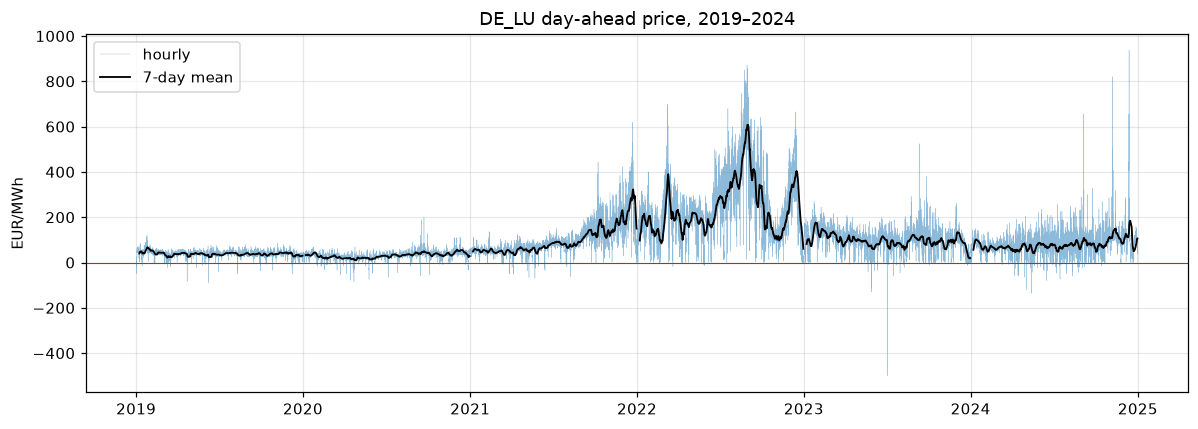

In [3]:
fig, ax = plt.subplots()
ax.plot(df.index, df["price"], lw=0.25, alpha=0.5, label="hourly")
ax.plot(df.index, df["price"].rolling(168).mean(), color="black", lw=1.2, label="7-day mean")
ax.axhline(0, color="crimson", lw=0.7)
ax.set_ylabel("EUR/MWh"); ax.set_title("DE_LU day-ahead price, 2019–2024")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

### 2b. Zoom: the 2021–2023 crisis

Where the tail lives.

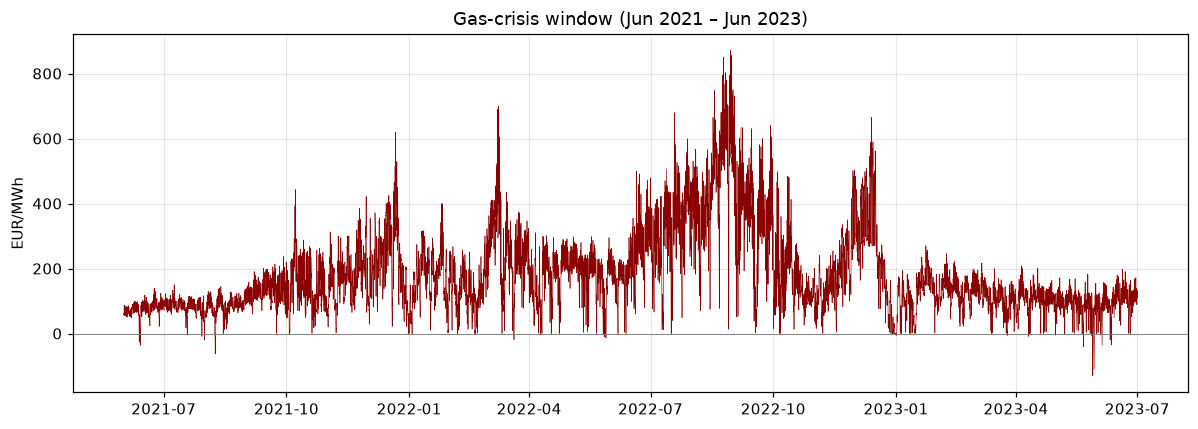

In [4]:
crisis = df.loc["2021-06":"2023-06", "price"]
fig, ax = plt.subplots()
ax.plot(crisis.index, crisis, lw=0.4, color="darkred")
ax.axhline(0, color="grey", lw=0.6)
ax.set_ylabel("EUR/MWh"); ax.set_title("Gas-crisis window (Jun 2021 – Jun 2023)")
plt.tight_layout(); plt.show()

## 3. Price distribution — heavy tails vs Gaussian

A normal curve fitted to the same mean/variance is overlaid. The empirical
distribution has far more mass in the extremes than the Gaussian allows — this is
*exactly* why historical VaR beats parametric (Gaussian) VaR for power, the key
Phase 2 interview point.

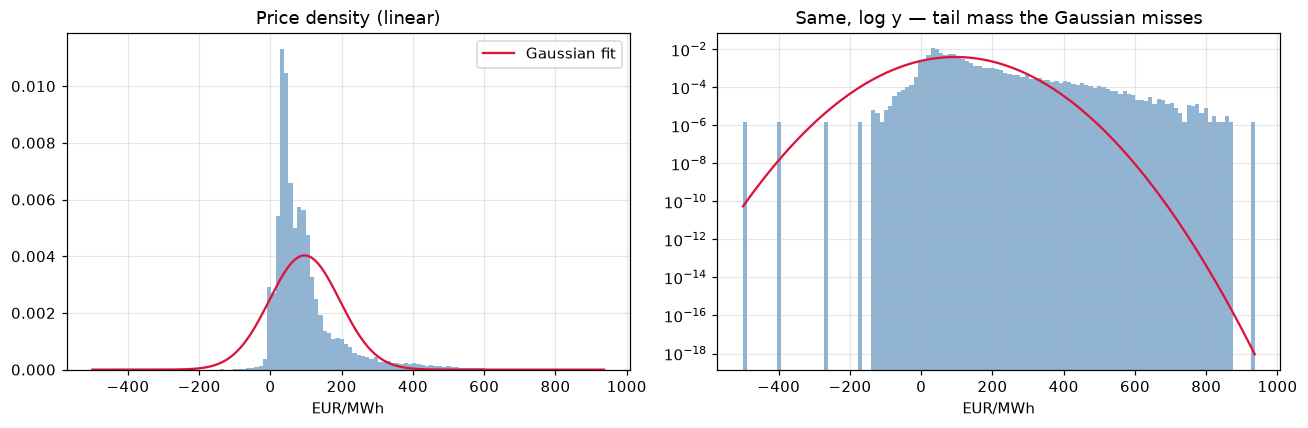

    0.1%  ->     -65.2 EUR/MWh
    1.0%  ->      -8.5 EUR/MWh
    5.0%  ->       5.0 EUR/MWh
   50.0%  ->      66.2 EUR/MWh
   95.0%  ->     299.9 EUR/MWh
   99.0%  ->     500.1 EUR/MWh
   99.9%  ->     703.2 EUR/MWh


In [5]:
p = df["price"].dropna()
mu, sigma = p.mean(), p.std()
x = np.linspace(p.min(), p.max(), 400)
normal = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(p, bins=120, density=True, alpha=0.6, color="steelblue")
axes[0].plot(x, normal, color="crimson", lw=1.5, label="Gaussian fit")
axes[0].set_title("Price density (linear)"); axes[0].set_xlabel("EUR/MWh"); axes[0].legend()

axes[1].hist(p, bins=120, density=True, alpha=0.6, color="steelblue")
axes[1].plot(x, normal, color="crimson", lw=1.5)
axes[1].set_yscale("log")
axes[1].set_title("Same, log y — tail mass the Gaussian misses")
axes[1].set_xlabel("EUR/MWh")
plt.tight_layout(); plt.show()

for q in [0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]:
    print(f"  {q:6.1%}  ->  {p.quantile(q):8.1f} EUR/MWh")

## 4. Negative prices

Real and structural in DE_LU: when must-run + renewable supply exceeds demand,
generators pay to keep producing. Counting them per year shows the upward trend
as renewable penetration grows.

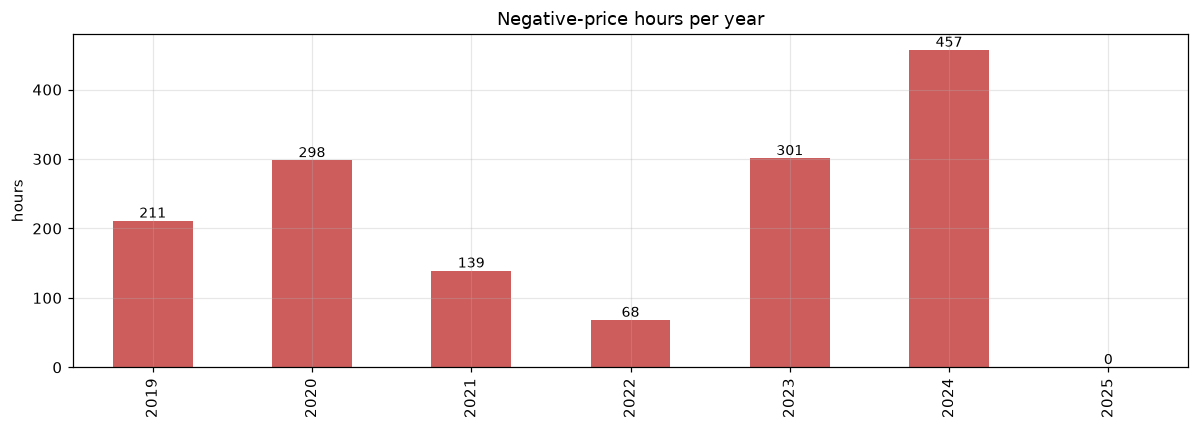

In [6]:
neg = (df["price"] < 0).groupby(df.index.year).sum()
ax = neg.plot(kind="bar", color="indianred")
ax.set_ylabel("hours"); ax.set_title("Negative-price hours per year")
for i, v in enumerate(neg): ax.text(i, v, str(int(v)), ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

## 5. Daily and weekly seasonality

The average shape of a day (morning + evening demand peaks, solar-driven midday
dip) and the weekday/weekend split. This is the deterministic structure the
`hour` / `dow` / `is_weekend` calendar features encode.

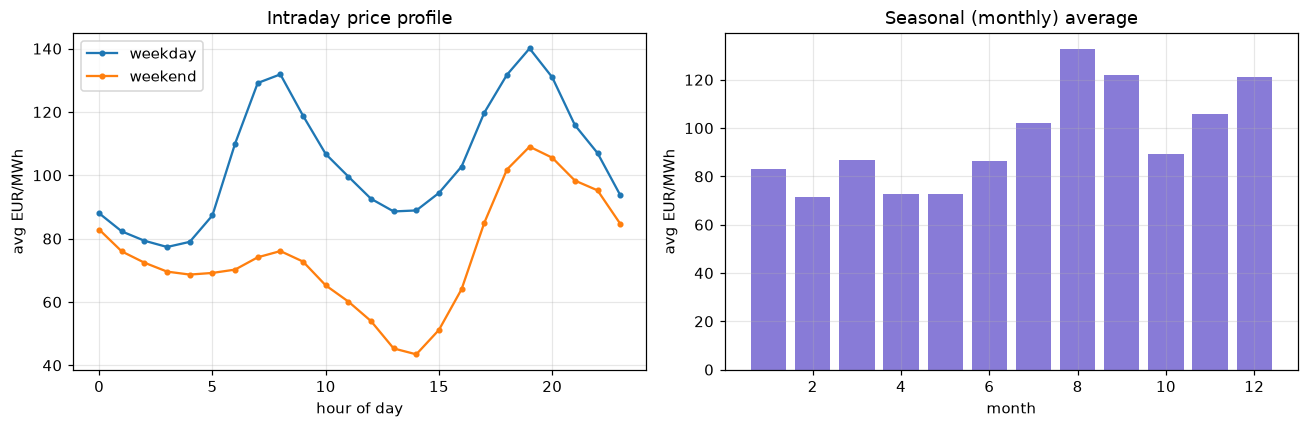

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

wk = df[df["is_weekend"] == 0].groupby("hour")["price"].mean()
we = df[df["is_weekend"] == 1].groupby("hour")["price"].mean()
axes[0].plot(wk.index, wk, marker="o", ms=3, label="weekday")
axes[0].plot(we.index, we, marker="o", ms=3, label="weekend")
axes[0].set_xlabel("hour of day"); axes[0].set_ylabel("avg EUR/MWh")
axes[0].set_title("Intraday price profile"); axes[0].legend()

mon = df.groupby("month")["price"].mean()
axes[1].bar(mon.index, mon, color="slateblue", alpha=0.8)
axes[1].set_xlabel("month"); axes[1].set_ylabel("avg EUR/MWh")
axes[1].set_title("Seasonal (monthly) average")
plt.tight_layout(); plt.show()

## 6. Residual load → price: the merit-order curve

Residual load (demand minus renewables) is *the* price driver. Plotting price
against it traces the supply stack: cheap when residual load is low (renewables
cover it, prices can go negative), rising steeply as expensive peakers are
dispatched. A binned median makes the curve readable through the scatter.

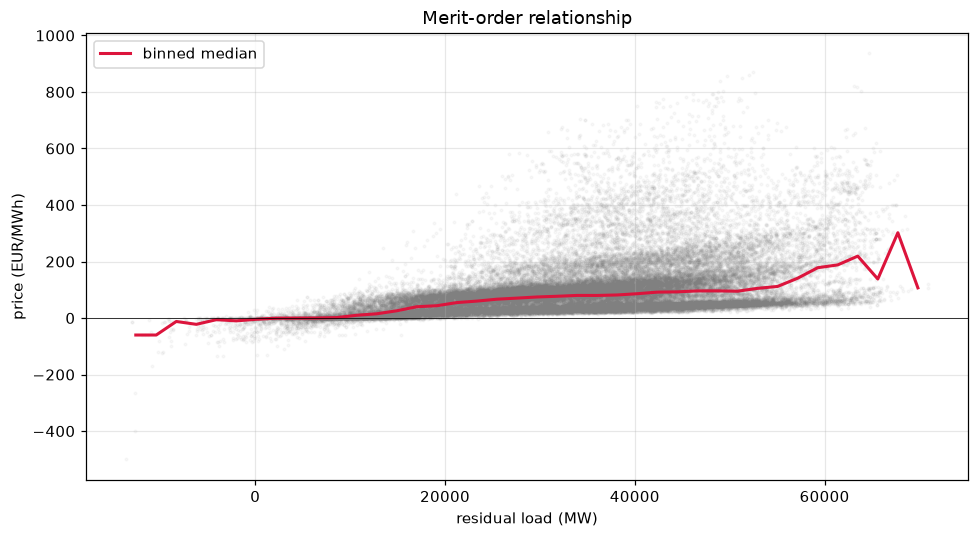

In [8]:
rl = df[["residual_load", "price"]].dropna()
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(rl["residual_load"], rl["price"], s=3, alpha=0.05, color="grey")

bins = pd.cut(rl["residual_load"], 40)
med = rl.groupby(bins, observed=True)["price"].median()
centers = [iv.mid for iv in med.index]
ax.plot(centers, med.values, color="crimson", lw=2, label="binned median")
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("residual load (MW)"); ax.set_ylabel("price (EUR/MWh)")
ax.set_title("Merit-order relationship"); ax.legend()
plt.tight_layout(); plt.show()

## 7. Autocorrelation — why lag-24 and lag-168

The forecast uses `price_lag_24` (same hour yesterday) and `price_lag_168` (same
hour last week). This ACF shows *why*: sharp peaks at multiples of 24h (daily
cycle) and a strong peak at 168h (weekly cycle). The chosen lags sit exactly on
those peaks. The 24h floor also respects gate closure — nothing more recent than
D-1 is known at noon, so no leakage.

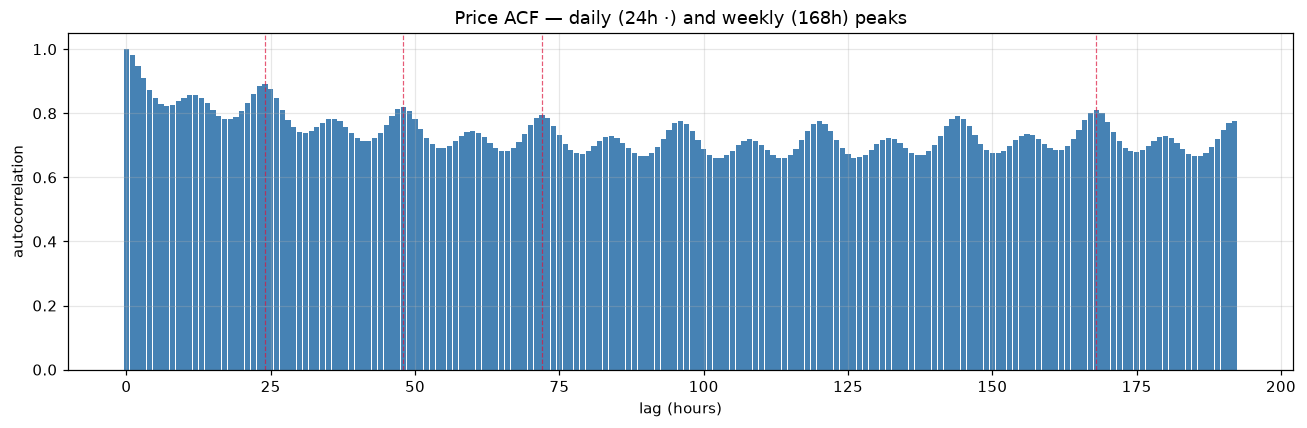

ACF at lag 24: 0.891  | lag 168: 0.812


In [9]:
def acf(series, max_lag):
    s = series.dropna()
    s = s - s.mean()
    denom = (s**2).sum()
    return np.array([(s * s.shift(l)).sum() / denom for l in range(max_lag + 1)])

a = acf(df["price"], 192)
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(a)), a, color="steelblue", width=0.9)
for L in (24, 48, 72, 168):
    ax.axvline(L, color="crimson", lw=0.8, ls="--", alpha=0.7)
ax.set_xlabel("lag (hours)"); ax.set_ylabel("autocorrelation")
ax.set_title("Price ACF — daily (24h ·) and weekly (168h) peaks")
plt.tight_layout(); plt.show()
print("ACF at lag 24:", round(a[24], 3), " | lag 168:", round(a[168], 3))

## 8. Missing-data map

Where the NaNs are. The lag/rolling features carry expected warm-up NaNs at the
very start of the series (no week-ago price yet); those rows should be dropped
before training. Anything else nonzero is worth investigating.

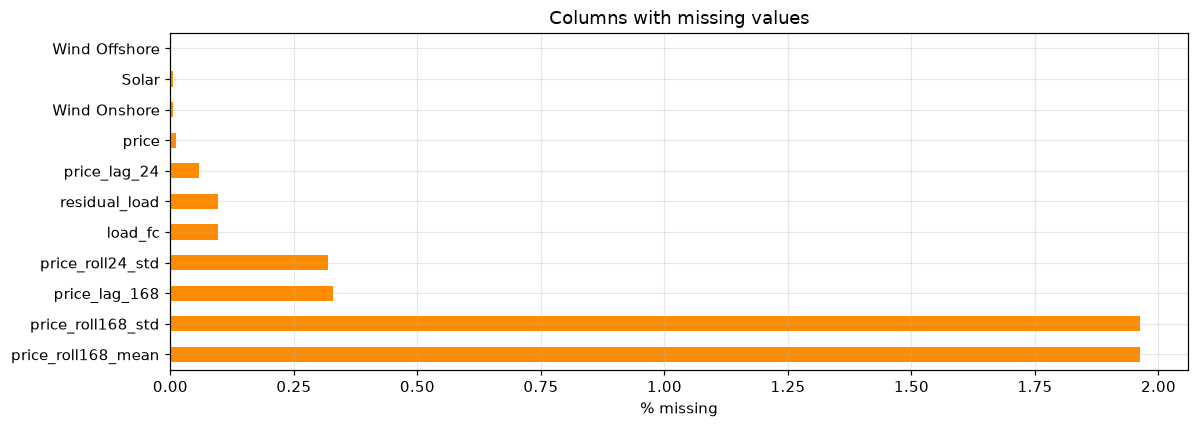

price_roll168_mean    1.961642
price_roll168_std     1.961642
price_lag_168         0.328841
price_roll24_std      0.319337
load_fc               0.096942
residual_load         0.096942
price_lag_24          0.057024
price                 0.011405
Wind Onshore          0.005702
Solar                 0.005702
Wind Offshore         0.001901
dtype: float64

In [10]:
nan_pct = (df.isna().mean() * 100).sort_values(ascending=False)
nan_pct = nan_pct[nan_pct > 0]
if len(nan_pct):
    ax = nan_pct.plot(kind="barh", color="darkorange")
    ax.set_xlabel("% missing"); ax.set_title("Columns with missing values")
    plt.tight_layout(); plt.show()
else:
    print("No missing values.")
nan_pct